# Imports


In [46]:
import pandas as pd
import re
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels import robust


warnings.filterwarnings("ignore")


PATH = "../data/raw/listing.csv"
REPORTS = "../reports/"
OUTPUT = "../data/raw/listings_cleaned.csv"

df = pd.read_csv(PATH)
len(df)

14185

In [47]:
%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)


# Cleaning


## Property Condition


In [48]:
df = df[df['bedrooms']<=4]
df

,url,title,description,fetch_date,house_type,bathrooms,bedrooms,price,locality,Condition,...,Kitchen Cabinets,Kitchen Shelf,Microwave,Pop Ceiling,Pre-Paid Meter,Refrigerator,TV,Tiled Floor,Wardrobe,Wi-Fi
0,https://jiji.com.gh/cantonments/houses-apartme...,"4bdrm Townhouse / Terrace in Cantoments, Canto...",4 bedrooms all rooms en-suite \nThree floors a...,2025-12-26 21:14:51.680707,Townhouse / Terrace,5,4,49500.0,Cantonments,Newly-Built,...,1,1,0,0,0,1,0,0,0,0
1,https://jiji.com.gh/ledzokuku-krowor/houses-ap...,"1bdrm Apartment in Teshie Nungua, Ledzokuku-Kr...",Wall and gated spacious single self contained ...,2025-12-26 21:14:51.677264,Apartment,1,1,1200.0,Ledzokuku-Krowor,Fairly Used,...,0,0,0,0,0,0,0,0,0,0
2,https://jiji.com.gh/east-legon/houses-apartmen...,1bdrm Room & Parlour in East Legon for rent,Newly built Executive chamber and hall self ap...,2025-12-26 21:14:51.674819,Room & Parlour,1,1,4000.0,East Legon,Newly-Built,...,1,0,0,1,1,0,0,1,1,0
4,https://jiji.com.gh/pillar-2/houses-apartments...,1bdrm Apartment in Francis Quarcoe Pillar 2 fo...,Newly Built Single Room Self Contained For Ren...,2025-12-26 21:14:51.667797,Apartment,1,1,1200.0,Dome,Newly-Built,...,1,1,0,0,0,0,0,1,0,0
5,https://jiji.com.gh/airport-residential-area/h...,Furnished 4bdrm House in Airport Residential A...,4 Bedroom furnished house with 2 bedroom boy's...,2025-12-26 21:14:51.664126,House,4,4,65000.0,Airport Residential Area,Newly-Built,...,1,1,1,1,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14180,https://jiji.com.gh/dansoman/houses-apartments...,"1bdrm Apartment in Dansoman,Accra for rent","Modern chamber and Hall apartment, Spacious ro...",NaN,Apartment,1,1,2150.0,Dansoman,Fairly Used,...,1,1,0,1,1,0,0,0,0,0
14181,https://jiji.com.gh/dome/houses-apartments-for...,"1bdrm Apartment in Kisseman, Dome for rent",Neat single room self contained at kisseman \n...,NaN,Apartment,1,1,1400.0,Dome,Fairly Used,...,1,1,0,1,1,0,0,1,0,0
14182,https://jiji.com.gh/teshie-new-town/houses-apa...,"2bdrm Apartment in Grada Estates, New Town for...","Newly built two bedrooms with two washroom, ai...",NaN,Apartment,2,2,6000.0,Teshie,Newly-Built,...,1,0,0,1,1,0,0,1,1,1
14183,https://jiji.com.gh/tema-metropolitan/houses-a...,4bdrm House in Tema Metropolitan for rent,2 bedroom self compound house for rent in Tema...,NaN,House,3,4,14000.0,Tema Metropolitan,Fairly Used,...,1,1,0,0,1,0,0,1,1,0


In [49]:
fc = [r"\$", "dollars", "dollar", "usd"]
fc_pattern = "|".join(fc)
has_fc = df["description"].str.contains(fc_pattern, case=False, na=False)
df.loc[has_fc, "price_tag"] = "foreign"

In [50]:
x = np.log1p(df["price"])

q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1

l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"l1: {l1} l2: {l2}")

l1: 4.926939272685674 l2: 12.058840771080499


In [51]:
def plot_price(df, cutoff=5000, l1=12, l2=17):
    plt.figure(num=1, figsize=(20, 10), linewidth=1)
    plt.subplot2grid((2, 3), (0, 0))
    sns.distplot(df["price"])
    plt.subplot2grid((2, 3), (0, 1))
    sns.distplot(np.log1p(df["price"]))
    plt.axvline(x=l1, color="b", linestyle=":")
    plt.axvline(x=l2, color="b", linestyle=":")
    plt.xlabel("log(1+price)")
    ax = plt.subplot2grid((2, 3), (0, 2))
    sm.qqplot(np.log1p(df["price"]), stats.norm, fit=True, line="45", ax=ax)
    plt.subplot2grid((2, 3), (1, 0), colspan=3)
    red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
    df.price.plot(kind="box", xlim=(0, cutoff), vert=False, flierprops=red)

    plt.tight_layout()


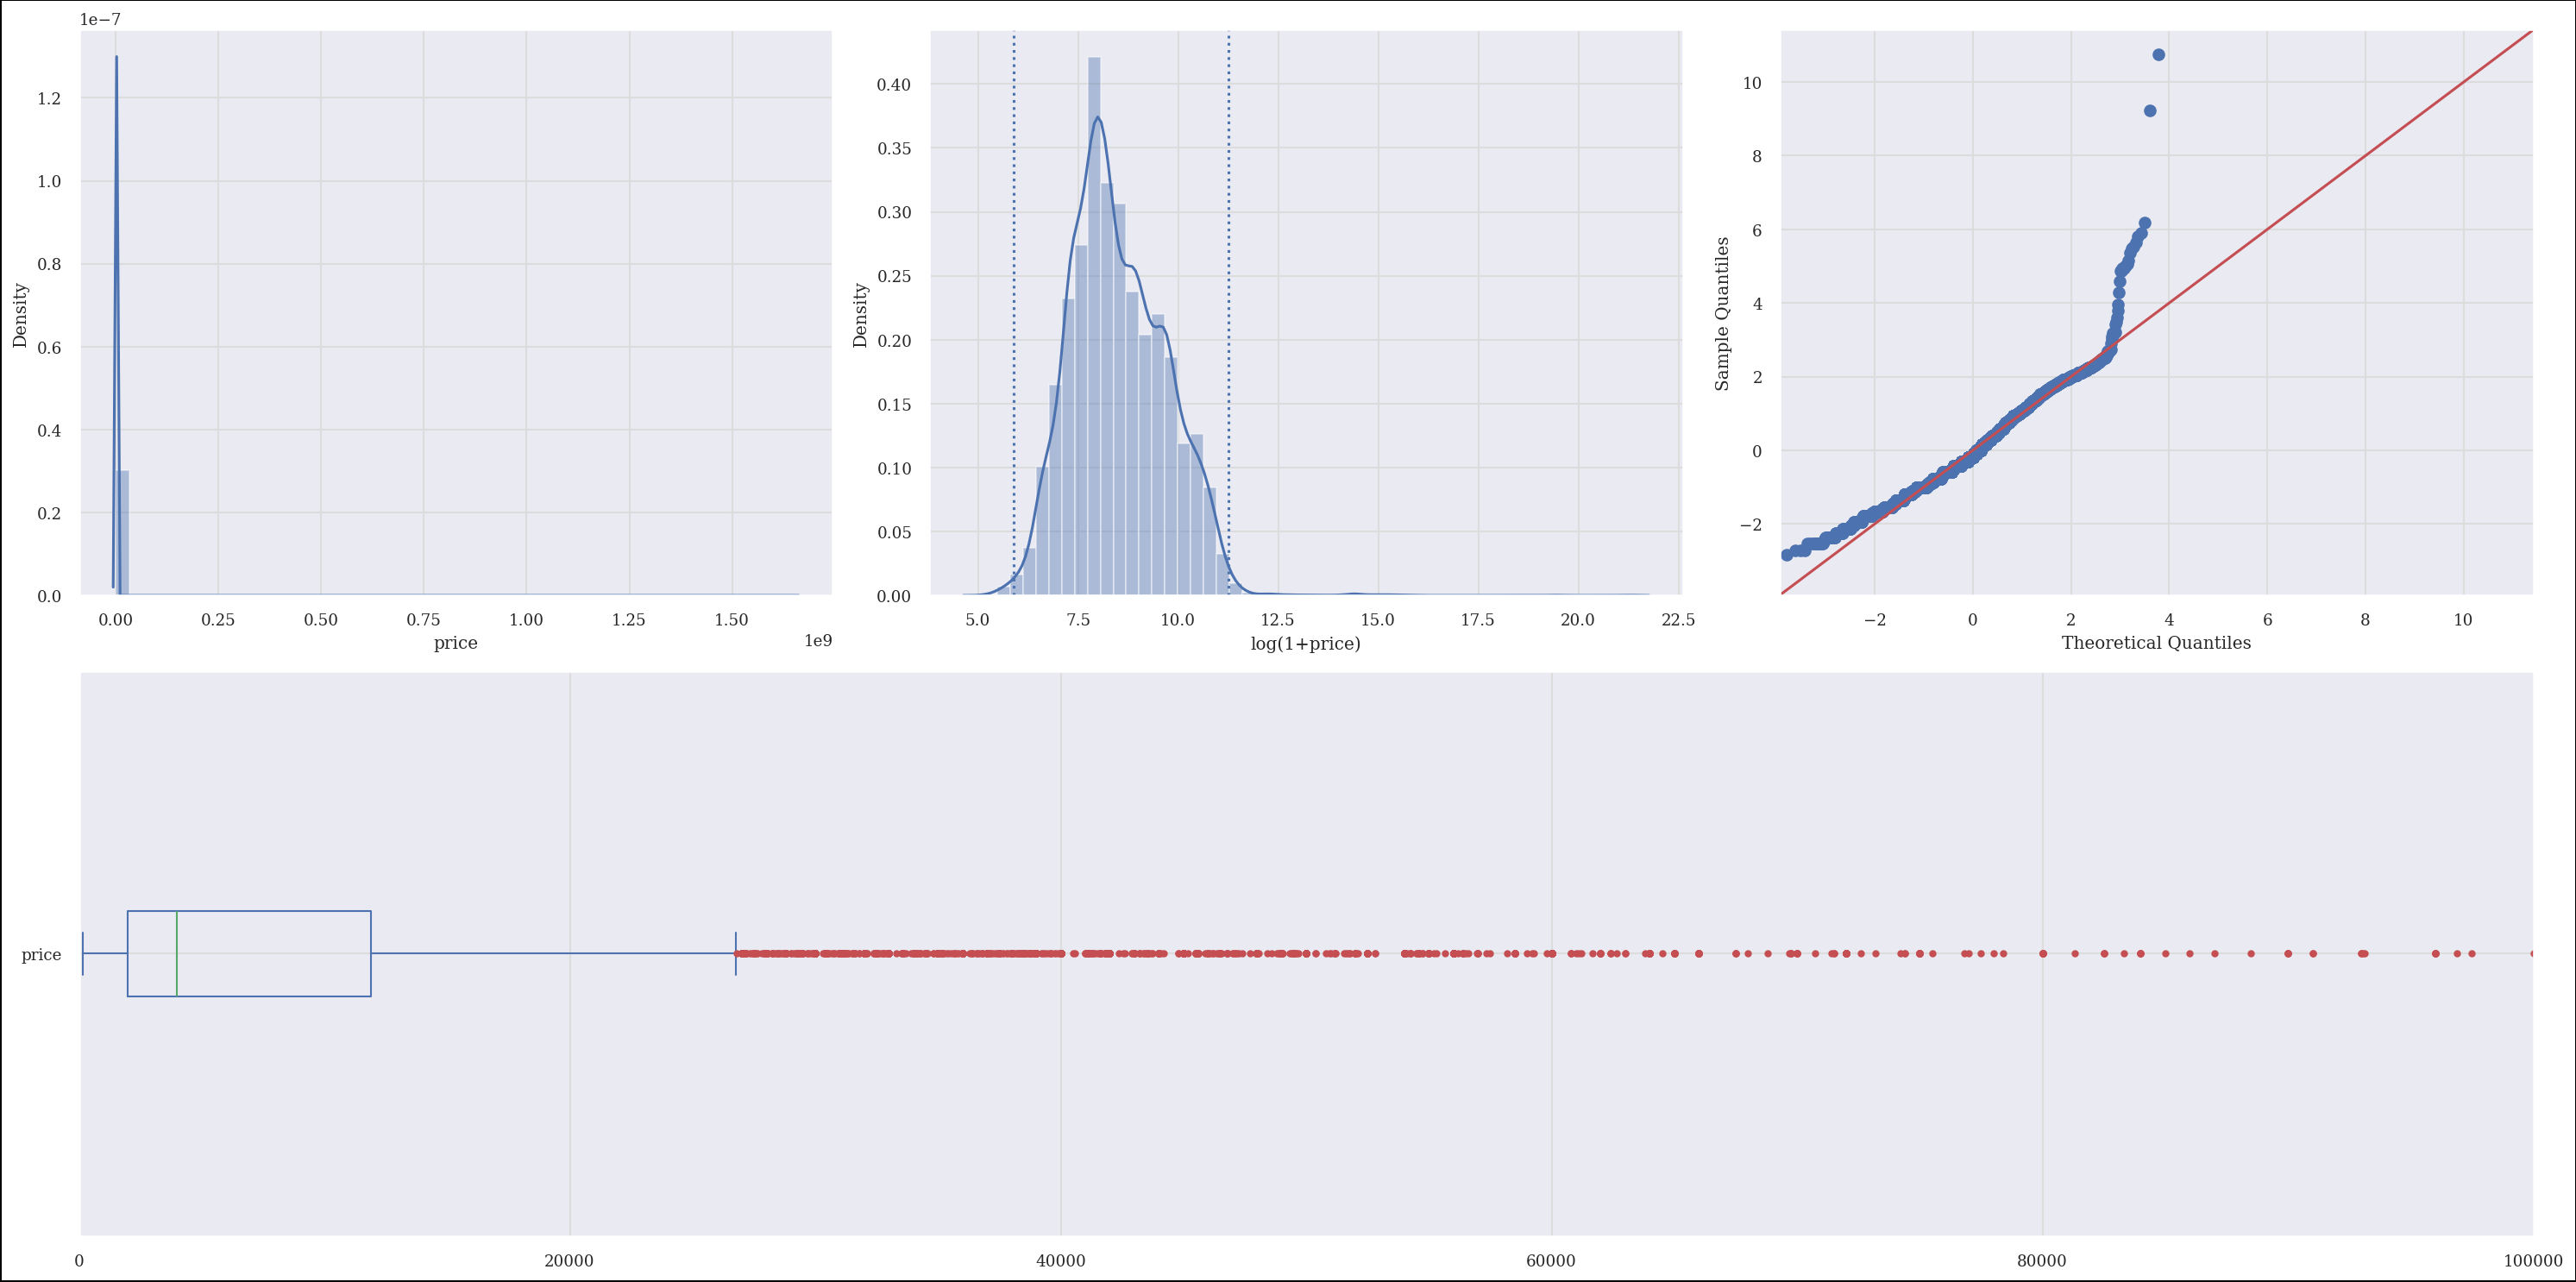

In [52]:
l1 = 5.9
l2 = 11.25
plot_price(df, cutoff=100_000, l1=l1, l2=l2)


In [53]:
outliers = df[(np.log1p(df["price"]) < l1) | (np.log1p(df["price"]) > l2)]
print(f"Number of listings which are found to outliers: {len(outliers)}\n")
print(f"Outlier range: prices below {np.exp(l1) - 1} and above {np.exp(l2) - 1}")


Number of listings which are found to outliers: 140

Outlier range: prices below 364.0374678653289 and above 76878.91976467776


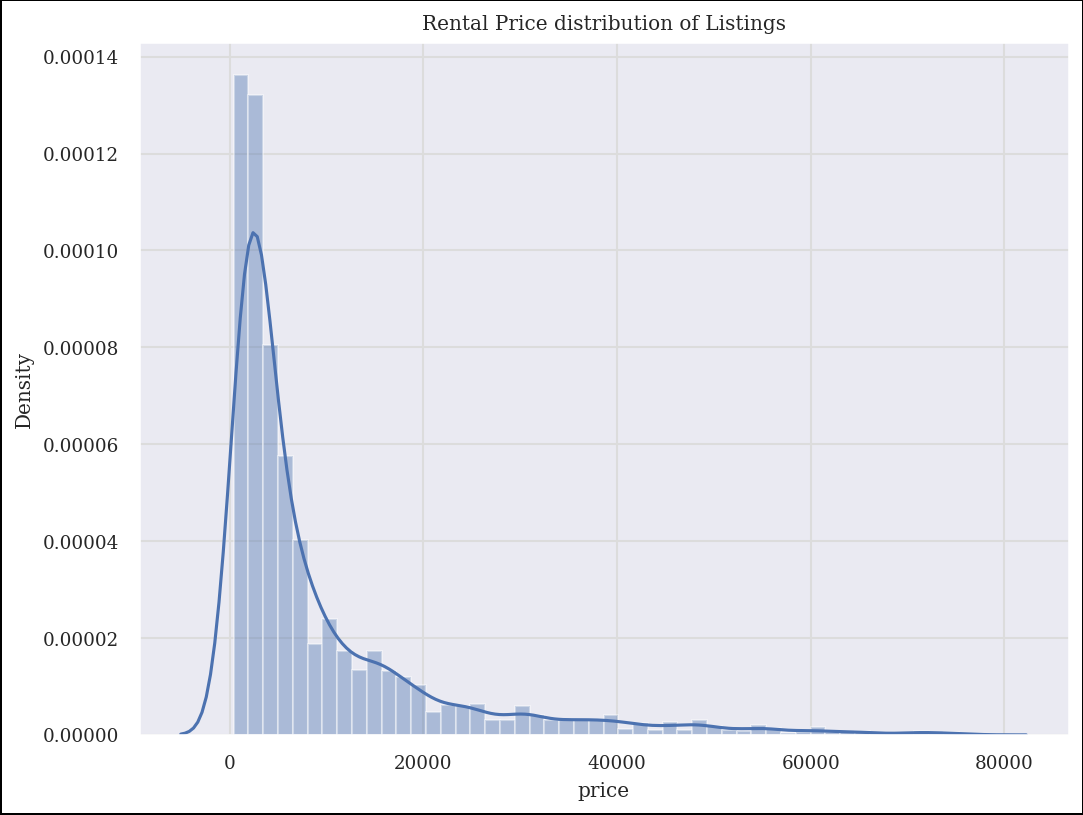

In [54]:
plt.figure(num=1, figsize=(8, 6), linewidth=1)
rental_df = df.drop(index=outliers.index)
sns.distplot(rental_df.price)

_ = plt.title("Rental Price distribution of Listings")


In [56]:
rental_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13050 entries, 0 to 14184
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  13050 non-null  object 
 1   title                13050 non-null  object 
 2   description          13050 non-null  object 
 3   fetch_date           12898 non-null  object 
 4   house_type           13050 non-null  object 
 5   bathrooms            13050 non-null  int64  
 6   bedrooms             13050 non-null  int64  
 7   price                13050 non-null  float64
 8   locality             13050 non-null  object 
 9   Condition            13050 non-null  object 
 10  Furnishing           13050 non-null  object 
 11  property_size        13050 non-null  float64
 12  24-hour Electricity  13050 non-null  int64  
 13  Air Conditioning     13050 non-null  int64  
 14  Apartment            13050 non-null  int64  
 15  Balcony              13050 non-null  int6